# Análise de Dados e montagem de modelo em requesitos de Vinhos

##Introdução



A qualidade de um vinho é um dos principais fatores que influenciam sua aceitação no mercado, seu posicionamento comercial e seu valor agregado. Tradicionalmente, essa avaliação é realizada por especialistas por meio de análises sensoriais, considerando aspectos como aroma, sabor, equilíbrio e textura. Entretanto, esse processo é naturalmente subjetivo e pode variar de acordo com a experiência de cada avaliador, tornando difícil garantir um padrão consistente entre diferentes análises.

Com o avanço da Ciência de Dados e do Aprendizado de Máquina, tornou-se possível utilizar informações físico-químicas obtidas durante o processo de produção para estimar a qualidade de um vinho antes mesmo da avaliação humana. Essa abordagem permite apoiar enólogos e produtores na tomada de decisão, reduzir custos com testes sensoriais e identificar oportunidades de melhoria durante o processo produtivo.

Neste projeto será utilizada a base de dados WineQT, composta por diversas características físico-químicas de amostras de vinho e pela nota de qualidade atribuída por especialistas. Conforme proposto no desafio, a variável quality será transformada em um problema de classificação binária, onde:

Alta qualidade: qualidade maior ou igual a 7;
Baixa/Média qualidade: qualidade inferior a 7.

Essa transformação permite construir modelos de classificação capazes de prever se um vinho possui alta qualidade apenas a partir de suas características laboratoriais.

Para atingir esse objetivo, será realizada inicialmente uma etapa de pré-processamento dos dados, seguida por uma Análise Exploratória de Dados (EDA), permitindo compreender o comportamento das variáveis, identificar padrões, verificar a existência de inconsistências e selecionar informações relevantes para o treinamento dos modelos de Machine Learning. Posteriormente, diferentes algoritmos serão comparados por meio de métricas de desempenho, buscando identificar o modelo mais adequado para esse problema de classificação.

###Variáveis Analisadas

A base de dados contém variáveis físico-químicas medidas em laboratório, cada uma representando uma característica importante do vinho durante sua produção. Embora nenhuma dessas variáveis determine isoladamente a qualidade do produto, a combinação entre elas pode indicar padrões associados a vinhos considerados de alta qualidade.



####Fixed Acidity (Acidez Fixa)

Representa a quantidade de ácidos não voláteis presentes no vinho, como o ácido tartárico.

Importância para o negócio

A acidez fixa influencia diretamente a estabilidade química, a conservação e o equilíbrio do vinho. Valores muito baixos podem resultar em bebidas pouco estruturadas, enquanto valores muito elevados podem comprometer a experiência sensorial.


####Volatile Acidity (Acidez Volátil)

Corresponde principalmente ao ácido acético presente no vinho.

Importância para o negócio

É uma das variáveis mais importantes da base, pois concentrações elevadas estão frequentemente associadas a processos de fermentação inadequados, oxidação e deterioração do produto.

Para produtores, controlar essa variável significa reduzir perdas de produção e aumentar a probabilidade de obtenção de vinhos de melhor qualidade.


####Citric Acid (Ácido Cítrico)

Quantidade de ácido cítrico presente no vinho.

Importância para o negócio

O ácido cítrico contribui para a sensação de frescor e pode auxiliar na estabilidade microbiológica do produto. Além disso, costuma estar relacionado ao equilíbrio entre acidez e sabor.

Será analisado se maiores concentrações apresentam alguma associação com vinhos de maior qualidade.



####Residual Sugar (Açúcar Residual)

Quantidade de açúcar que permanece no vinho após o processo de fermentação.

Importância para o negócio

Esse parâmetro influencia diretamente o perfil sensorial do vinho, podendo indicar vinhos mais secos ou mais doces.

Dependendo do tipo de vinho produzido, níveis elevados ou reduzidos podem impactar positivamente ou negativamente sua avaliação.



####Chlorides (Cloretos)

Representa a concentração de sais presentes no vinho.

Importância para o negócio

Valores elevados podem indicar problemas durante o processamento ou contaminação, afetando o sabor e reduzindo a percepção de qualidade pelo consumidor.

Durante a análise será investigado se existe relação entre níveis de cloretos e a classificação final.

Free Sulfur Dioxide (Dióxido de Enxofre Livre)

Quantidade de dióxido de enxofre disponível para proteger o vinho.

Importância para o negócio

O dióxido de enxofre livre atua como antioxidante e antimicrobiano, aumentando a vida útil do produto.

Níveis insuficientes favorecem a deterioração, enquanto concentrações excessivas podem alterar características sensoriais.



####Total Sulfur Dioxide (Dióxido de Enxofre Total)

Representa a soma do dióxido de enxofre livre e combinado.

Importância para o negócio

Permite avaliar a quantidade total de conservantes presentes no vinho, sendo um indicador importante do processo de conservação.

Sua análise ajuda a compreender se diferentes níveis estão associados à qualidade atribuída pelos especialistas.



####Density (Densidade)

Mede a densidade do vinho.

Importância para o negócio

A densidade está relacionada principalmente ao teor de açúcar e álcool presentes na bebida.

Por reunir informações indiretas sobre outras propriedades físico-químicas, essa variável pode contribuir significativamente para os modelos preditivos.



####pH

Representa o nível de acidez da bebida.

Importância para o negócio

O pH influencia estabilidade química, crescimento microbiológico e conservação do vinho.

Manter o pH dentro de faixas adequadas é essencial para preservar sabor, aroma e durabilidade.



####Sulphates (Sulfatos)

Concentração de sulfatos presentes no vinho.

Importância para o negócio

Os sulfatos contribuem para a estabilidade microbiológica e podem influenciar positivamente algumas características sensoriais.

Sua relação com a qualidade será investigada durante a análise exploratória.



####Alcohol (Teor Alcoólico)

Representa o percentual de álcool presente no vinho.

Importância para o negócio

É uma das variáveis frequentemente associadas à qualidade do vinho em estudos científicos, pois está relacionada ao equilíbrio entre corpo, aroma e percepção gustativa.

Durante a análise será investigado se maiores teores alcoólicos apresentam associação com notas mais elevadas.



####Quality (Qualidade)

Nota atribuída por especialistas.

Importância para o negócio

Essa variável representa a avaliação final do vinho realizada por especialistas e constitui a informação de referência para o treinamento dos modelos.

No entanto, conforme estabelecido pelo desafio, essa variável será transformada em uma classificação binária para simplificar o problema e permitir a construção de modelos capazes de distinguir entre vinhos de alta qualidade e vinhos de baixa ou média qualidade.

##Análise Exploratória de Dados (EDA)

###Preparando o ambiente



Importando as Libraries

In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Definindo Estilos de Gráficos

In [88]:
plt.style.use("default")
sns.set_theme(style="whitegrid")

Importando o Dataset

In [89]:
df = pd.read_csv('/content/WineQT.csv')

Analisando o dataset

In [90]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [91]:
df.shape

(1143, 13)

A tabela possui 1143 linhas (vinhos) e 13 colunas (Parâmetros da análise de qualidade)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [93]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [94]:
df.duplicated().sum()

np.int64(0)

O Dataset não possui nenhum valor nulo ou duplicado.

In [95]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [96]:
df = df.drop(columns=['Id'])

Coluna ID não será necessária para a nossa análise, neste momento.

In [97]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


###Criando a variável binária

Alta qualidade

nota ≥ 7

Baixa/média

nota < 7

In [98]:
df['quality_binary'] = np.where(df['quality'] >=7,1,0)

In [99]:
df[['quality', 'quality_binary']].head(10)

,quality,quality_binary
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0


###Analisando os dados


In [100]:
df['quality_binary'].value_counts()

,count
quality_binary,
0,984
1,159


In [101]:
df['quality_binary'].value_counts(normalize=True)*100

,proportion
quality_binary,
0,86.089239
1,13.910761


Temos então a seguinte proporção de vinhos:
0 = 86,1%
1 = 13,91%

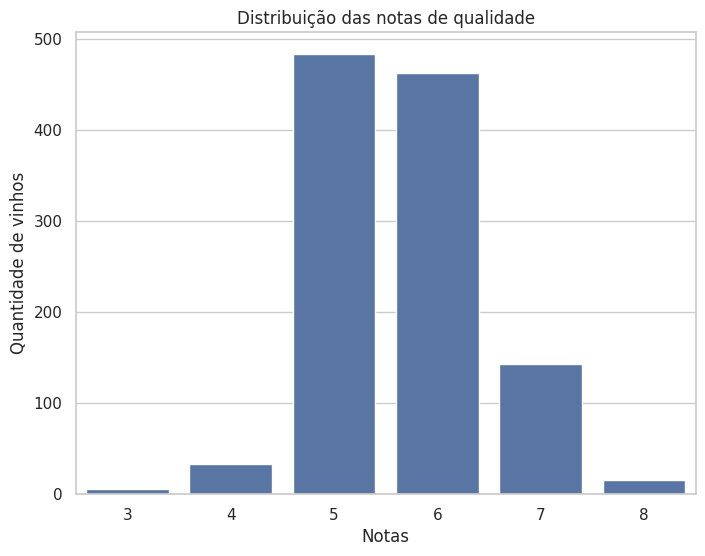

In [102]:
plt.figure(figsize=(8,6))

sns.countplot(data=df, x='quality')

plt.title('Distribuição das notas de qualidade')
plt.xlabel('Notas')
plt.ylabel('Quantidade de vinhos')

plt.show()


A maioria dos vinhos analisados recebeu a nota 5, seguido pela nota 6 e depois, com bastante diferença, pela nota 7.

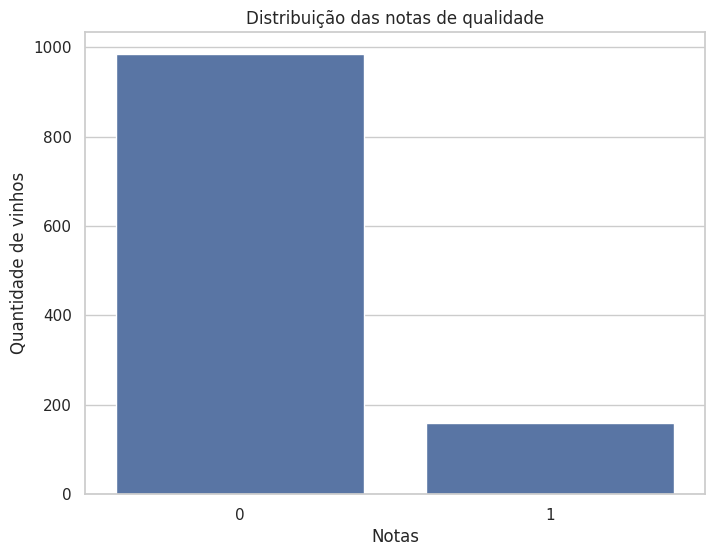

In [103]:
plt.figure(figsize=(8,6))

sns.countplot(data=df, x='quality_binary')

plt.title('Distribuição das notas de qualidade')
plt.xlabel('Notas')
plt.ylabel('Quantidade de vinhos')

plt.show()

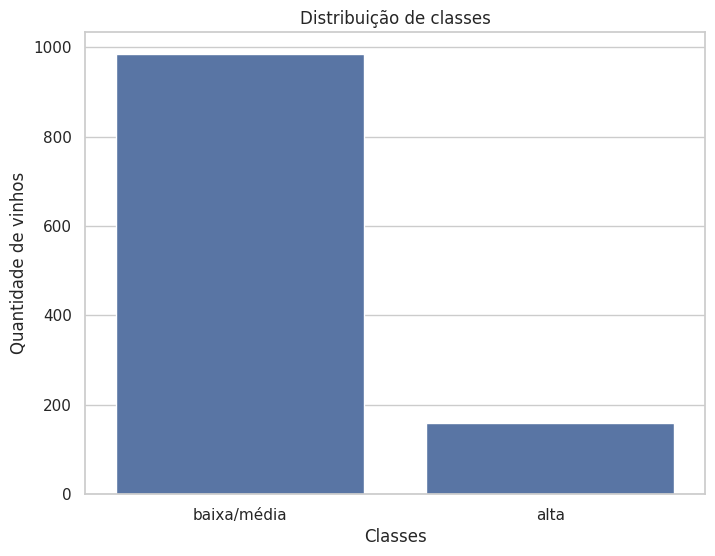

In [104]:
plt.figure(figsize=(8,6))

sns.countplot(data=df, x='quality_binary')

plt.title('Distribuição de classes')
plt.xlabel("Classes")
plt.ylabel('Quantidade de vinhos')
plt.xticks([0,1], ['baixa/média','alta'])

plt.show()

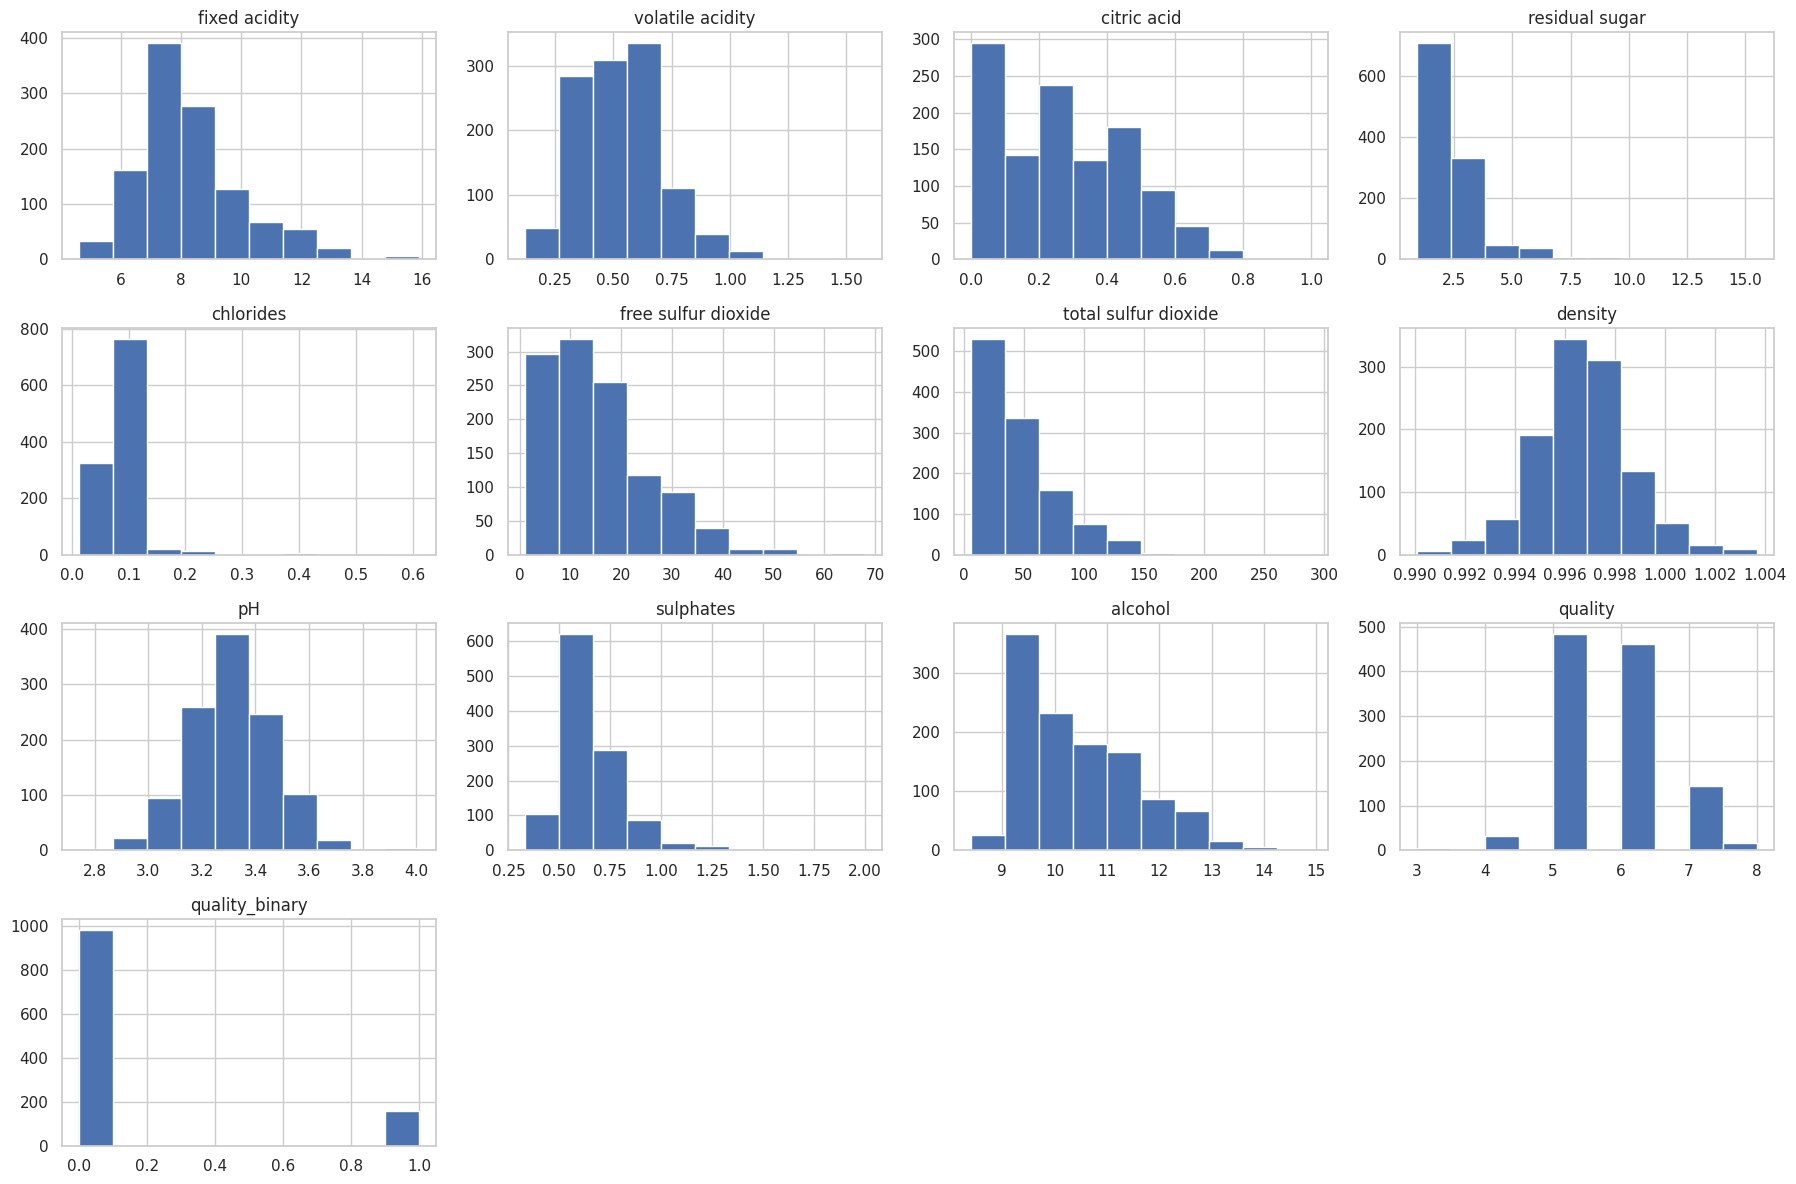

In [105]:
df.hist(figsize=(18,12))

plt.tight_layout()

plt.show()

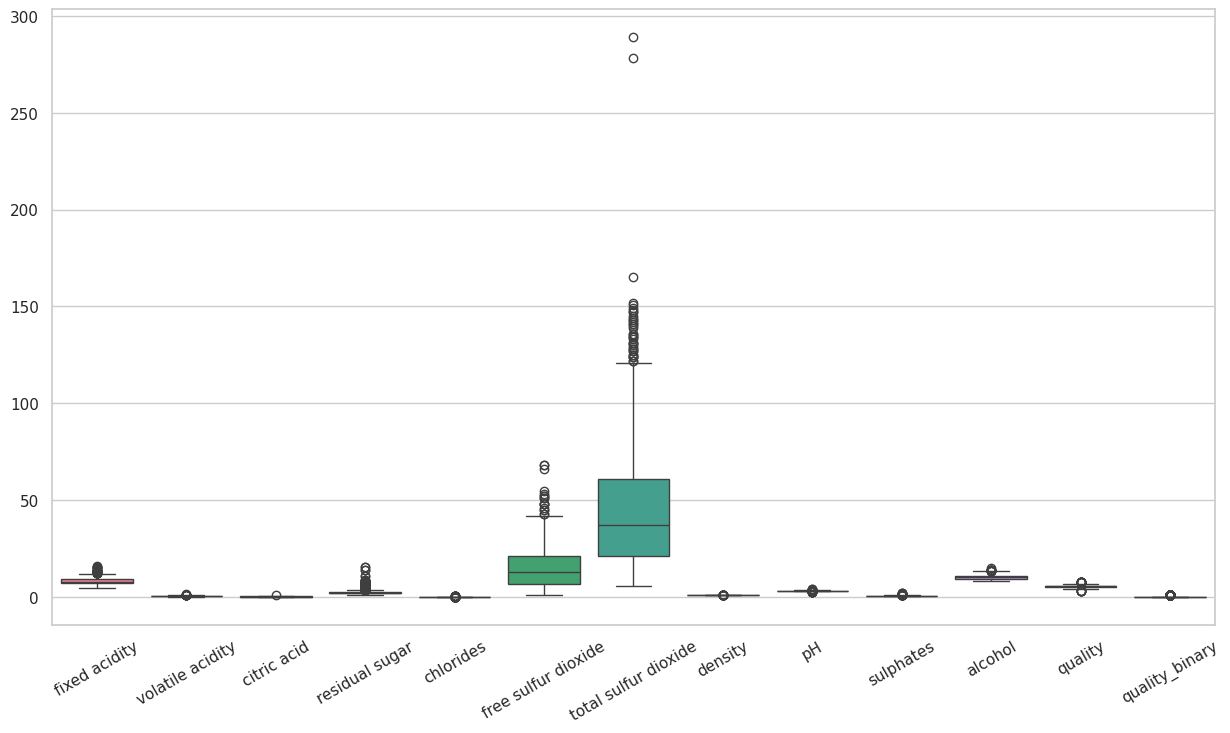

In [106]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=30)

plt.show()

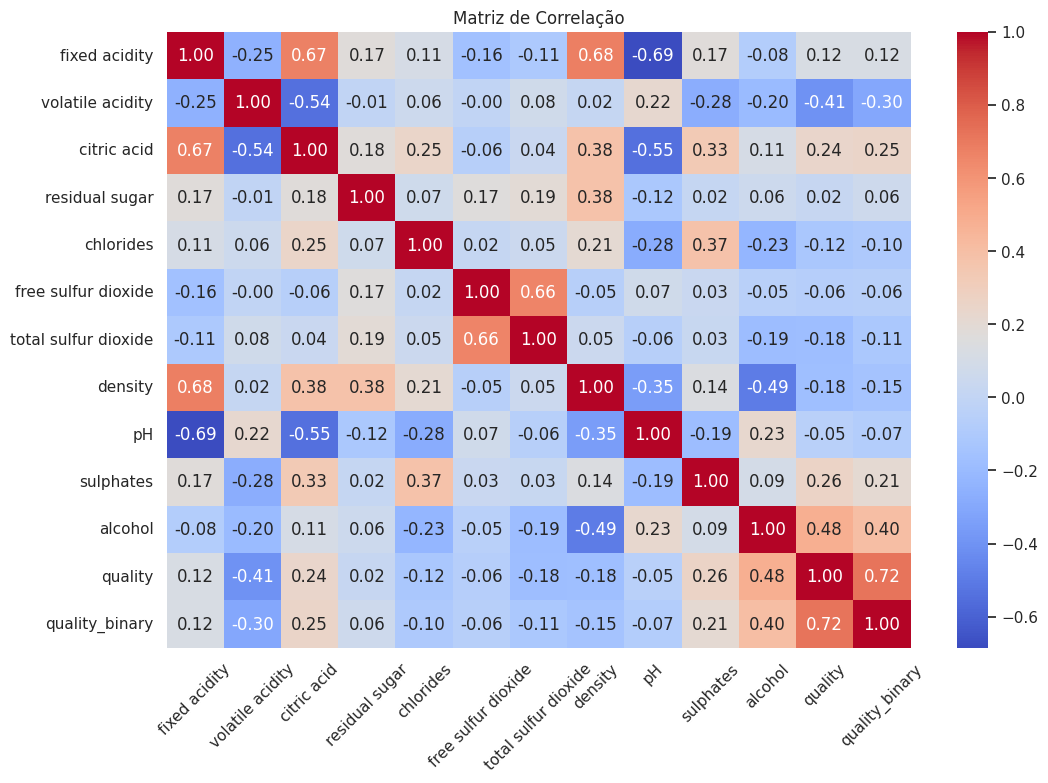

In [175]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.xticks(rotation=45)

plt.title("Matriz de Correlação")

plt.show()

In [108]:
correlacao = df.corr()['quality'].sort_values(ascending=False)

print(correlacao)

quality                 1.000000
quality_binary          0.720433
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


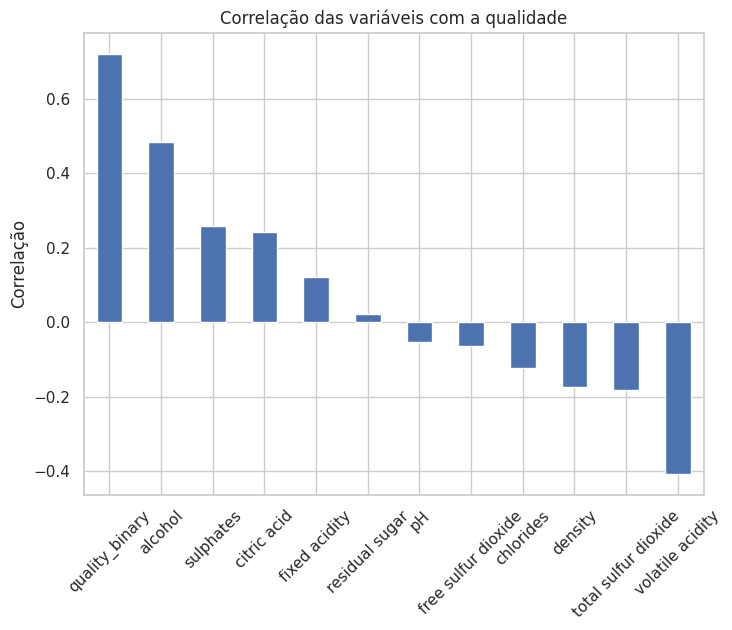

In [176]:
plt.figure(figsize=(8,6))

correlacao.drop('quality').plot(kind='bar')

plt.title("Correlação das variáveis com a qualidade")

plt.ylabel("Correlação")

plt.xticks(rotation=45)

plt.show()

O gráfico acima evidencia que o teor alcoólico (alcohol) apresenta a maior correlação positiva com a qualidade do vinho, enquanto a acidez volátil (volatile acidity) apresenta a maior correlação negativa. Essas variáveis foram selecionadas para análises mais detalhadas por demonstrarem maior potencial preditivo.

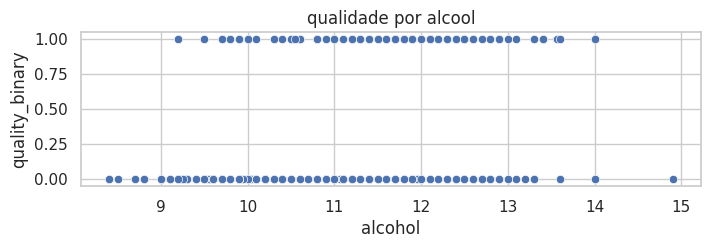

In [110]:
plt.figure(figsize=(8,2))

sns.scatterplot(data=df,
                x='alcohol',
                y='quality_binary')

plt.title("qualidade por alcool")

plt.show()

Os vinhos com maiores notas de qualidade possuem o teor alcoolico maiores

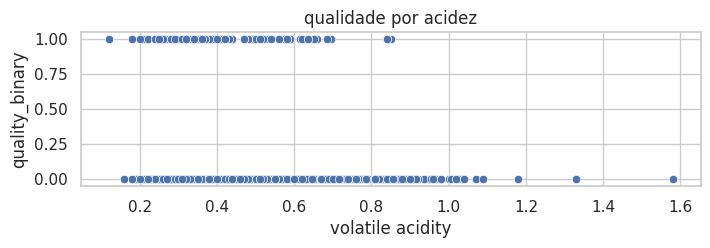

In [111]:
plt.figure(figsize=(8,2))

sns.scatterplot(data=df, x='volatile acidity', y='quality_binary')

plt.title("qualidade por acidez")

plt.show()

Correlacionando a qualidade e a acidez volátil dos vinhos, notamos que os vinhos de maior qualidade possuem acidez baixa, preferencialmente abaixo de 4.

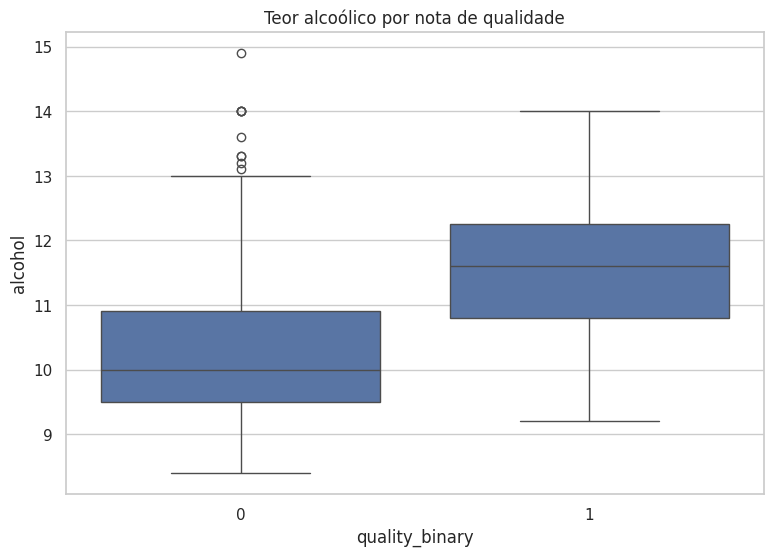

In [112]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df,
            x='quality_binary',
            y='alcohol')

plt.title("Teor alcoólico por nota de qualidade")

plt.show()

In [113]:
print(df['alcohol'].min())
print(df['alcohol'].max())

8.4
14.9


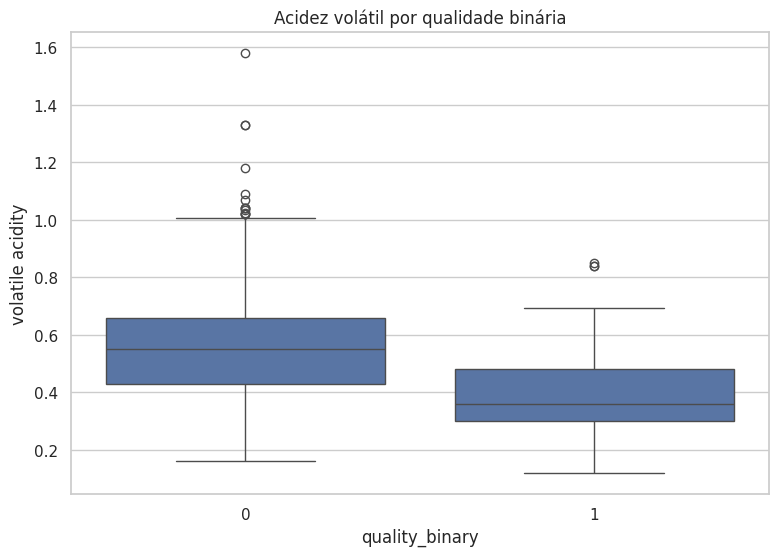

In [114]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df,
            x='quality_binary',
            y='volatile acidity')

plt.title("Acidez volátil por qualidade binária")

plt.show()

In [115]:
print(df['volatile acidity'].min())
print(df['volatile acidity'].max())

0.12
1.58



1. Acidez volátil
Observa-se que vinhos de maior qualidade apresentam menores níveis de acidez volátil. Além disso, os vinhos de baixa qualidade exibem maior dispersão e maior quantidade de outliers, indicando que valores elevados dessa variável estão associados à redução da qualidade do vinho.

2. Teor alcoólico
Os vinhos classificados como de maior qualidade apresentam, em média, maior teor alcoólico. A distribuição da variável encontra-se deslocada para valores superiores na classe 1, indicando uma associação positiva entre teor alcoólico e qualidade.

Em ambos os casos, a quantidade disparada de outliers aparece em maior parte nos vinhos de menor qualidade, demonstrando maior constância de valores nos vinhos de maior qualidade.



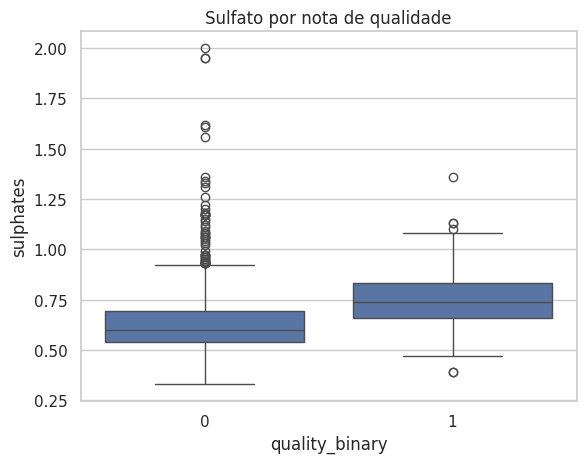

In [116]:
sns.boxplot(data=df,
            x='quality_binary',
            y='sulphates')

plt.title("Sulfato por nota de qualidade")

plt.show()

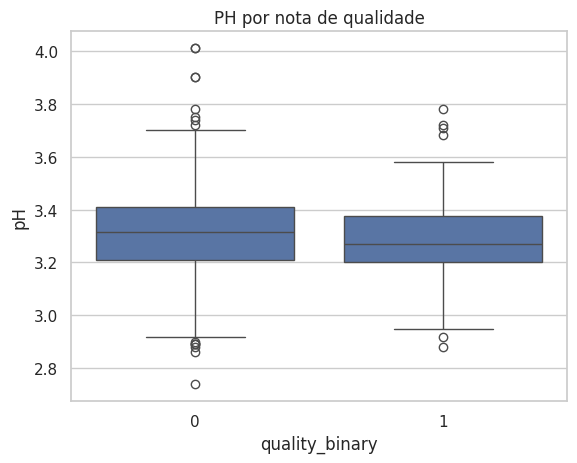

In [117]:
sns.boxplot(data=df,
            x='quality_binary',
            y='pH')

plt.title("PH por nota de qualidade")

plt.show()

Sulfatos: Os vinhos classificados como de maior qualidade apresentam, em média, maiores concentrações de sulfatos. Entretanto, a presença de muitos outliers na classe 0 indica que valores muito elevados de sulfatos, isoladamente, não garantem melhor qualidade do vinho.

PH: A variável pH apresenta distribuição bastante semelhante entre as duas classes de qualidade. As medianas são próximas e há grande sobreposição entre os intervalos interquartis, indicando que essa variável possui baixo poder de discriminação para diferenciar vinhos de maior e menor qualidade.



###Conclusão da Análise Exploratória

A análise exploratória permitiu compreender a distribuição das observações e identificar quais variáveis apresentam maior potencial para discriminar os vinhos de menor e maior qualidade. Inicialmente, verificou-se que a variável quality possui maior concentração de amostras nas notas intermediárias, justificando sua transformação em uma variável binária (quality_binary) para o problema de classificação.

A análise de correlação e dos boxplots evidenciou que o teor alcoólico (alcohol) e a acidez volátil (volatile acidity) são as variáveis que melhor diferenciam as duas classes. Os vinhos classificados como de maior qualidade apresentam, em geral, maior teor alcoólico e menor acidez volátil, indicando uma associação consistente entre essas características e a variável alvo. A variável sulphates também apresentou uma tendência de diferenciação entre as classes, embora menos pronunciada.

Por outro lado, a análise da variável pH mostrou distribuições muito semelhantes entre os grupos, com grande sobreposição entre os intervalos interquartis e medianas próximas. Esse resultado sugere que o pH possui baixo poder discriminatório para este conjunto de dados, evidenciando que nem todas as variáveis contribuem de forma significativa para a previsão da qualidade dos vinhos.

De forma geral, a análise exploratória permitiu identificar as características mais relevantes do conjunto de dados e forneceu evidências para a seleção das variáveis que serão utilizadas na etapa de modelagem. As análises indicam que alcohol e volatile acidity apresentam maior potencial preditivo, enquanto variáveis como pH tendem a contribuir menos para a diferenciação entre as classes.

##Machine Learning

###Importando bibliotecas e definindo as variáveis

In [146]:
from sklearn import *

In [147]:
from sklearn.model_selection import train_test_split

In [148]:
x = df[['alcohol', 'volatile acidity', 'fixed acidity', 'citric acid','residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']]

In [149]:
x

,alcohol,volatile acidity,fixed acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
0,9.4,0.700,7.4,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56
1,9.8,0.880,7.8,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68
2,9.8,0.760,7.8,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65
3,9.8,0.280,11.2,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58
4,9.4,0.700,7.4,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56
...,...,...,...,...,...,...,...,...,...,...,...
1138,11.0,0.510,6.3,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75
1139,9.5,0.620,6.8,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82
1140,10.5,0.600,6.2,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58
1141,11.2,0.550,5.9,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76


In [150]:
y = df['quality_binary']

###Definindo base de teste

In [151]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size = 0.3,
    stratify=y,
    random_state = 42)

In [152]:
len(x_train)

800

In [153]:
len(x_test)

343

In [154]:
y_train

,quality_binary
1130,0
143,1
774,0
399,0
671,1
...,...
938,0
947,0
453,0
385,0


A base de teste está definida e randomizada

In [155]:
print(f"Quantidade de amostras para treino: {len(x_train)}")
print(f"Quantidade de amostras para teste: {len(x_test)}")

Quantidade de amostras para treino: 800
Quantidade de amostras para teste: 343


O conjunto de dados foi dividido em 80% para treinamento e 30% para teste, resultando em 800 amostras utilizadas para treinar os modelos e 343 amostras reservadas para avaliar seu desempenho. Essa separação permite medir a capacidade de generalização do modelo utilizando dados que não foram vistos durante o treinamento.

###Pré-Processamento: Normalizando os Dados de Treino e Teste

In [156]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

x_train_normalizado = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x.columns,
    index=x_train.index)

x_test_normalizado = pd.DataFrame(
    scaler.transform(x_test),
    columns=x.columns,
    index=x_test.index)

print('Treino normalizado')
display(x_train_normalizado.head())

print('Teste Normalizado:')
display(x_test_normalizado.head())

Treino normalizado


,alcohol,volatile acidity,fixed acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
1130,0.625000,0.190083,0.254545,0.434211,0.102740,0.093489,0.123077,0.070671,0.339941,0.434783,0.166667
143,0.339286,0.165289,0.454545,0.618421,0.034247,0.073456,0.123077,0.063604,0.505140,0.313043,0.302469
774,0.428571,0.500000,0.181818,0.118421,0.315068,0.175292,0.123077,0.038869,0.475771,0.426087,0.098765
399,0.482143,0.433884,1.000000,0.644737,0.226027,0.138564,0.138462,0.060071,0.960352,0.052174,0.253086
671,0.714286,0.132231,0.336364,0.631579,0.082192,0.135225,0.076923,0.021201,0.294420,0.347826,0.179012


Teste Normalizado:


,alcohol,volatile acidity,fixed acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates
832,0.500000,0.628099,0.172727,0.039474,0.321918,0.111853,0.338462,0.144876,0.414831,0.626087,0.104938
201,0.375000,0.231405,0.390909,0.421053,0.321918,0.125209,0.138462,0.144876,0.662996,0.452174,0.271605
221,0.196429,0.239669,0.518182,0.552632,0.102740,0.335559,0.076923,0.028269,0.685022,0.286957,0.179012
778,0.642857,0.305785,0.254545,0.355263,0.082192,0.098497,0.200000,0.067138,0.279736,0.426087,0.185185
868,0.928571,0.247934,0.045455,0.000000,0.061644,0.053422,0.261538,0.289753,0.110132,0.713043,0.246914


No código acima eu decidi tratar normalizar os dados, pois são muitas variáveis e todas possuem numerações diferentes, o que pode trazer muita discrepância na hora da análise e da aplicação do modelo.

###Aplicando Modelo 1 - Regressão Logística

Como primeiro algoritmo foi escolhida a "Regressão Logística". Segundo meus estudos, este algorítmo é bastante utilizado em problemas de classificação binária. Como esse modelo é sensível à escala das variáveis, serão utilizados os dados normalizados obtidos na etapa de pré-processamento.

In [157]:
from sklearn.linear_model import LogisticRegression

In [158]:
modelo_lr = LogisticRegression( random_state=42,
                               max_iter=1000)

####Treinando o modelo 1

In [159]:
modelo_lr.fit(
    x_train_normalizado,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [160]:
y_pred_lr = modelo_lr.predict(
    x_test_normalizado
)

y_prob_lr = modelo_lr.predict_proba(
    x_test_normalizado
)[:,1]

####Avaliando o modelo

In [161]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [162]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8571428571428571
Precision: 0.47058823529411764
Recall   : 0.16666666666666666
F1-score : 0.24615384615384617
ROC AUC  : 0.7882768361581921


In [163]:
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       295
           1       0.47      0.17      0.25        48

    accuracy                           0.86       343
   macro avg       0.67      0.57      0.58       343
weighted avg       0.82      0.86      0.83       343



####Matriz de Confusão

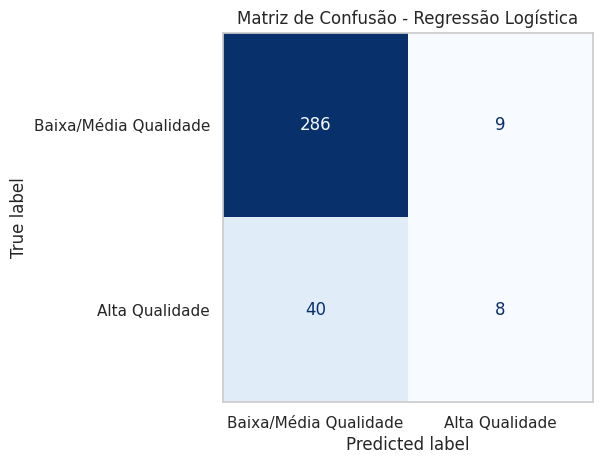

In [164]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Baixa/Média Qualidade", "Alta Qualidade"],
    cmap="Blues",
    colorbar=False
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.grid(False)
plt.show()

In [165]:
print("Quantidade de vinhos no conjunto de teste:", len(y_test))

Quantidade de vinhos no conjunto de teste: 343


####Analisando o Modelo 1 - Regressão Logística

Os resultados obtidos demonstram que a Regressão Logística foi eficiente para classificar vinhos de baixa e média qualidade, apresentando elevada acurácia geral (85,7%). Entretanto, o modelo encontrou dificuldades para identificar corretamente os vinhos classificados como de alta qualidade, refletidas principalmente pelo baixo Recall (16,7%) e pelo baixo F1-score (24,6%). Apesar da boa capacidade discriminatória indicada pelo ROC-AUC (0,788), observa-se que o algoritmo apresenta limitações diante do desbalanceamento entre as classes.

###Aplicando Modelo 2 - Random Forest

In [166]:
from sklearn.ensemble import RandomForestClassifier

In [167]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42)

In [168]:
modelo_rf.fit(
    x_train_normalizado,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

####Previsões do Modelo 2 - Random Forest

In [169]:
y_pred_rf = modelo_rf.predict(
    x_test_normalizado
)

y_prob_rf = modelo_rf.predict_proba(
    x_test_normalizado
)[:,1]

####Avaliação do modelo 2 - Random Forest

In [170]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8979591836734694
Precision: 0.6756756756756757
Recall   : 0.5208333333333334
F1-score : 0.5882352941176471
ROC AUC  : 0.8588983050847457


####Matriz de confusão - Modelo 2 - Random Forest

<Figure size 600x500 with 0 Axes>

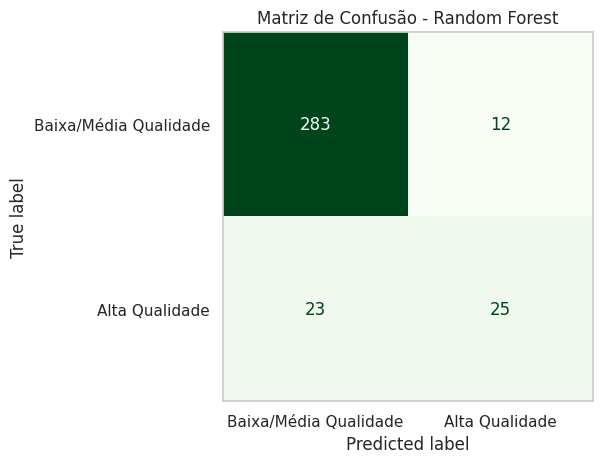

In [171]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Baixa/Média Qualidade", "Alta Qualidade"],
    cmap="Greens",
    colorbar=False
)

plt.title("Matriz de Confusão - Random Forest")
plt.grid(False)
plt.show()

####Avaliando o modelo 2 - Random Forest

Os resultados demonstram que a Random Forest foi o modelo com melhor desempenho para o problema de classificação da qualidade dos vinhos. Além de apresentar maior acurácia geral (89,8%), o algoritmo obteve ganhos expressivos nas métricas de Precision, Recall, F1-score e ROC-AUC em relação à Regressão Logística. O aumento do Recall evidencia que a Random Forest conseguiu identificar corretamente um número significativamente maior de vinhos de alta qualidade, reduzindo a quantidade de falsos negativos.

###Comparação dos modelos testados

In [172]:
comparacao = pd.DataFrame({
    "Modelo": ["Regressão Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparacao

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regressão Logística,0.857143,0.470588,0.166667,0.246154,0.788277
1,Random Forest,0.897959,0.675676,0.520833,0.588235,0.858898


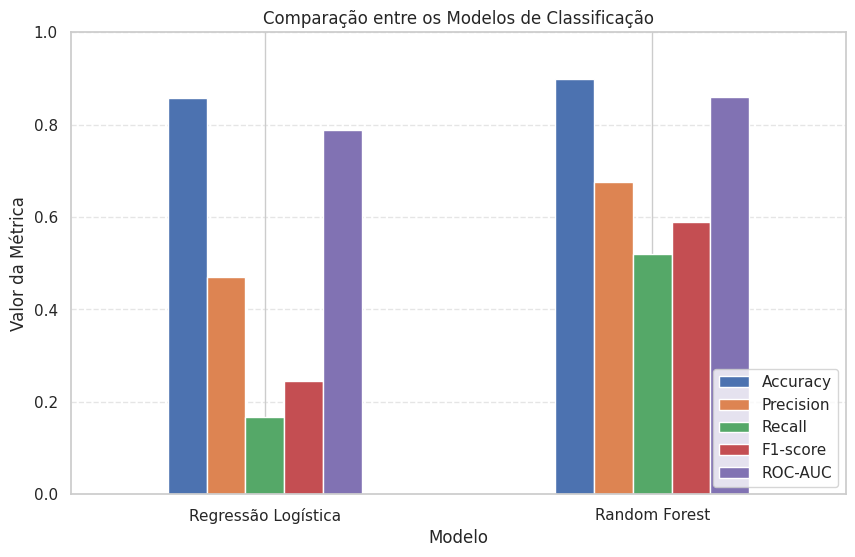

In [173]:
import matplotlib.pyplot as plt

comparacao_plot = comparacao.set_index("Modelo")

comparacao_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparação entre os Modelos de Classificação")
plt.ylabel("Valor da Métrica")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(loc="lower right")

plt.show()

A comparação entre os modelos demonstrou que ambos foram capazes de classificar a qualidade dos vinhos, porém a Random Forest apresentou desempenho superior em todas as métricas avaliadas. Enquanto a Regressão Logística mostrou bom desempenho geral, apresentou dificuldade em identificar corretamente os vinhos de alta qualidade, refletida principalmente pelo baixo Recall e F1-score. A Random Forest, por sua vez, conseguiu capturar melhor as relações entre as variáveis físico-químicas do vinho, aumentando significativamente a capacidade de identificar a classe positiva. Dessa forma, considerando Accuracy, Precision, Recall, F1-score e ROC-AUC, a Random Forest foi o modelo mais adequado para o problema proposto, atendendo de forma mais eficiente ao objetivo de prever a qualidade dos vinhos a partir de suas características físico-químicas.
